# Revisão de código 

Olá! 

Meu nome é Suelen. Estou feliz em revisar seu projeto hoje!

Quando vejo um erro pela primeira vez, apenas aponto. Deixarei você encontrá-lo e corrigi-lo sozinho. Além disso, ao longo do texto, farei algumas observações sobre melhorias no código e também farei comentários sobre suas percepções sobre o assunto. Mas se você ainda não consegue lidar com essa tarefa, darei uma dica mais precisa na próxima iteração e também alguns exemplos práticos. Estarei aberta a feedbacks e discussões sobre o tema.

Você pode encontrar meus comentários em caixas verdes, amarelas ou vermelhas como estas:


<div class="alert alert-block alert-success">
<b>Comentário: </b> <a class="tocSkip"></a>

Sucesso. Tudo está correto.
</div>

<div class="alert alert-block alert-warning">
<b>Comentário: </b> <a class="tocSkip"></a>

Observações. Algumas recomendações.
</div>

<div class="alert alert-block alert-danger">
<b>Comentário: </b> <a class="tocSkip"></a>

O bloco requer algumas correções. O trabalho não pode ser aceito com os comentários vermelhos.
</div>

Você pode me responder usando isto:

<div class="alert alert-block alert-info">
<b>Resposta do aluno</b> <a class="tocSkip"></a>
</div>



<div class="alert alert-block alert-success">

<b>Comentário geral:</b> <a class="tocSkip"></a>

Raphael, parabéns pela entrega! 👏  
Seu projeto está muito bem feito: o código é limpo, organizado e os comentários mostram que você realmente entende o que está fazendo.

Tudo fluiu de forma clara e objetiva, sem perder a atenção aos detalhes.

Está aprovado! Continue nesse caminho, você está mandando muito bem. 🚀

</div>

In [1]:
import pandas as pd

hypotheses = pd.read_csv('/datasets/hypotheses_us.csv', sep=';')

display(hypotheses)

,Hypothesis,Reach,Impact,Confidence,Effort
0,Add two new channels for attracting traffic. T...,3,10,8,6
1,Launch your own delivery service. This will sh...,2,5,4,10
2,Add product recommendation blocks to the store...,8,3,7,3
3,Change the category structure. This will incre...,8,3,3,8
4,Change the background color on the main page. ...,3,1,1,1
5,Add a customer review page. This will increase...,3,2,2,3
6,Show banners with current offers and sales on ...,5,3,8,3
7,Add a subscription form to all the main pages....,10,7,8,5
8,Launch a promotion that gives users discounts ...,1,9,9,5


In [2]:


hypotheses['ICE'] = (
    hypotheses['Impact'] * hypotheses['Confidence'] / hypotheses['Effort']
)

ice_sorted = hypotheses.sort_values(by='ICE', ascending=False)

display(ice_sorted[['Hypothesis', 'ICE']])


,Hypothesis,ICE
8,Launch a promotion that gives users discounts ...,16.200000
0,Add two new channels for attracting traffic. T...,13.333333
7,Add a subscription form to all the main pages....,11.200000
6,Show banners with current offers and sales on ...,8.000000
2,Add product recommendation blocks to the store...,7.000000
1,Launch your own delivery service. This will sh...,2.000000
5,Add a customer review page. This will increase...,1.333333
3,Change the category structure. This will incre...,1.125000
4,Change the background color on the main page. ...,1.000000


 <div class="alert alert-block alert-success">
<b> Comentário: </b> <a class="tocSkip"></a>
    
- RICE e ICE calculados com sucesso! 
- Foram adicionados comentários relevantes para análise


Sugestão de visualização:
Aqui você poderia plotar a distribuição dos atributos de cada hipótese usando um gráfico de caixa (boxplot). 
```python
df_hypotheses.drop(columns=['ICE', 'RICE']).boxplot(figsize=(10, 6))
... # seu código
```



Comparação entre ICE e RICE
Após calcular as duas métricas, é possível observar como a priorização muda quando incluímos o fator Reach no modelo RICE.
O método ICE considera apenas Impact, Confidence e Effort. Isso faz com que ideias com alto impacto e baixo esforço subam no ranking, mesmo que afetem poucos usuários. Ou seja, o ICE tende a favorecer iniciativas “boas e baratas”, mas que nem sempre geram valor em escala.
Já o RICE adiciona o fator Reach, que representa quantas pessoas serão impactadas pela ideia. Com isso, ideias que atingem um grande número de usuários sobem no ranking, mesmo que tenham impacto moderado. Por outro lado, ideias com alcance pequeno tendem a cair, mesmo que tenham um ICE alto.
Em resumo, o RICE muda a priorização ao destacar iniciativas que geram valor para mais pessoas, oferecendo uma visão mais estratégica e alinhada ao impacto total no negócio. Assim, a priorização final com RICE costuma ser mais realista e orientada a resultados amplos, enquanto o ICE é útil para uma avaliação inicial mais simples.


In [3]:


hypotheses['RICE'] = (
    hypotheses['Reach'] * hypotheses['Impact'] * hypotheses['Confidence'] / hypotheses['Effort']
) 

rice_sorted = hypotheses.sort_values(by='RICE', ascending=False)

display(rice_sorted[['Hypothesis', 'RICE']])


,Hypothesis,RICE
7,Add a subscription form to all the main pages....,112.0
2,Add product recommendation blocks to the store...,56.0
0,Add two new channels for attracting traffic. T...,40.0
6,Show banners with current offers and sales on ...,40.0
8,Launch a promotion that gives users discounts ...,16.2
3,Change the category structure. This will incre...,9.0
1,Launch your own delivery service. This will sh...,4.0
5,Add a customer review page. This will increase...,4.0
4,Change the background color on the main page. ...,3.0


In [4]:
import numpy as np
import matplotlib.pyplot as plt


In [5]:
orders = pd.read_csv('/datasets/orders_us.csv')
visits = pd.read_csv('/datasets/visits_us.csv')

orders['date'] = pd.to_datetime(orders['date'])
visits['date'] = pd.to_datetime(visits['date'])

display(orders.head())
print()
display(visits.head())


,transactionId,visitorId,date,revenue,group
0,3667963787,3312258926,2019-08-15,30.4,B
1,2804400009,3642806036,2019-08-15,15.2,B
2,2961555356,4069496402,2019-08-15,10.2,A
3,3797467345,1196621759,2019-08-15,155.1,B
4,2282983706,2322279887,2019-08-15,40.5,B


,date,group,visits
0,2019-08-01,A,719
1,2019-08-02,A,619
2,2019-08-03,A,507
3,2019-08-04,A,717
4,2019-08-05,A,756


In [6]:

print("Duplicados em orders:", orders.duplicated().sum())
print("Duplicados em visits:", visits.duplicated().sum())


users_in_A = orders[orders['group'] == 'A']['visitorId']
users_in_B = orders[orders['group'] == 'B']['visitorId']

users_in_both = np.intersect1d(users_in_A, users_in_B)

print("Usuários em ambos os grupos:", len(users_in_both))
users_in_both[:10]  

Duplicados em orders: 0
Duplicados em visits: 0
Usuários em ambos os grupos: 58


array([  8300375, 199603092, 232979603, 237748145, 276558944, 351125977,
       393266494, 457167155, 471551937, 477780734])

In [7]:

orders_clean = orders[~orders['visitorId'].isin(users_in_both)]


print("Pedidos antes:", len(orders))
print("Pedidos depois:", len(orders_clean))

Pedidos antes: 1197
Pedidos depois: 1016


In [8]:
orders_daily = (
    orders_clean
    .groupby(['date', 'group'], as_index=False)
    .agg({'transactionId': 'count', 'revenue': 'sum'})
)

orders_daily.columns = ['date', 'group', 'orders', 'revenue']

data = visits.merge(orders_daily, on=['date', 'group'], how='left')

data['orders'] = data['orders'].fillna(0)
data['revenue'] = data['revenue'].fillna(0)

data = data.sort_values(by=['date', 'group'])

display(data.head())

,date,group,visits,orders,revenue
0,2019-08-01,A,719,23,2266.6
31,2019-08-01,B,713,17,967.2
1,2019-08-02,A,619,19,1468.3
32,2019-08-02,B,581,23,2568.1
2,2019-08-03,A,507,24,1815.2


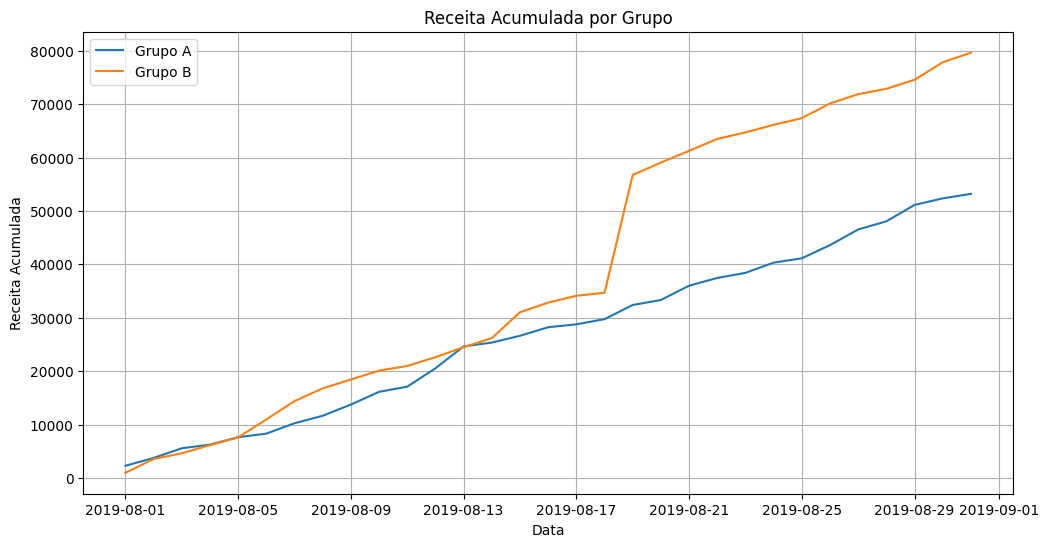

In [9]:
cumulative_revenue = (
    data.groupby(['date', 'group'])['revenue']
    .sum()
    .groupby(level=1)
    .cumsum()
    .reset_index()
)

plt.figure(figsize=(12, 6))
for grp in ['A', 'B']:
    grp_data = cumulative_revenue[cumulative_revenue['group'] == grp]
    plt.plot(grp_data['date'], grp_data['revenue'], label=f'Grupo {grp}')

plt.title('Receita Acumulada por Grupo')
plt.xlabel('Data')
plt.ylabel('Receita Acumulada')
plt.legend()
plt.grid(True)
plt.show()



O comportamento dos grupos A e B é bastante semelhante ao longo da maior parte do período. As curvas crescem de forma paralela e estável, indicando que ambos os grupos apresentam um desempenho parecido em termos de receita acumulada.
No entanto, entre 17/08 e 21/08, o grupo B apresenta um salto significativo, aumentando sua receita acumulada de forma mais abrupta do que o grupo A. Esse movimento cria uma diferença clara entre os grupos, que se mantém até o final do período.
Após esse pico, ambos os grupos voltam a crescer de maneira gradual e consistente, sem oscilações anormais.


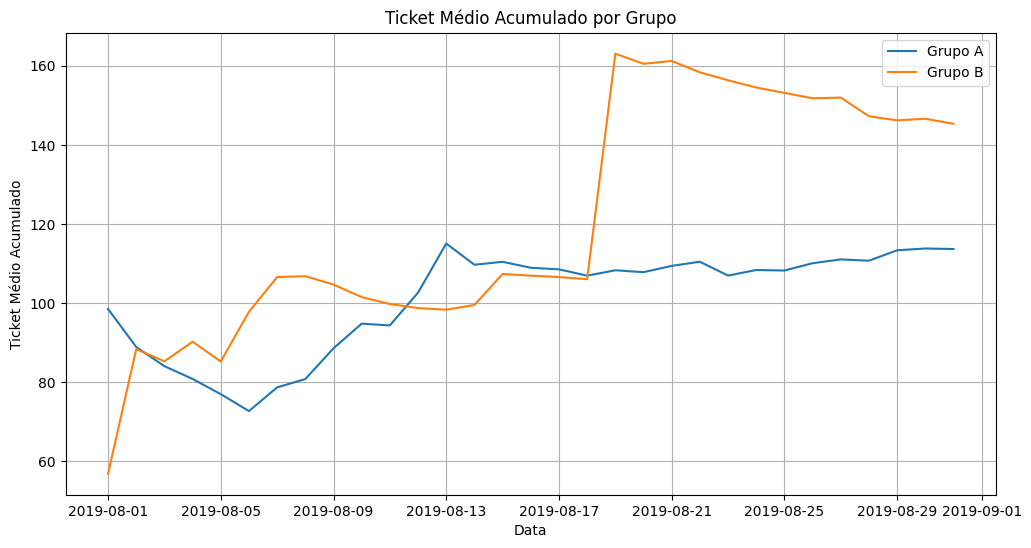

In [10]:
cumulative_data = (
    data.groupby(['date', 'group'])[['orders', 'revenue']]
    .sum()
    .groupby(level=1)
    .cumsum()
    .reset_index()
)


cumulative_data['avg_order_value'] = (
    cumulative_data['revenue'] / cumulative_data['orders']
)


plt.figure(figsize=(12, 6))
for grp in ['A', 'B']:
    grp_data = cumulative_data[cumulative_data['group'] == grp]
    plt.plot(grp_data['date'], grp_data['avg_order_value'], label=f'Grupo {grp}')

plt.title('Ticket Médio Acumulado por Grupo')
plt.xlabel('Data')
plt.ylabel('Ticket Médio Acumulado')
plt.legend()
plt.grid(True)
plt.show()

O ticket médio acumulado dos grupos A e B apresenta um comportamento estável ao longo do período analisado, sem oscilações que indiquem anomalias significativas. No início do teste, o grupo B mostra um aumento mais acentuado, enquanto o grupo A apresenta uma queda inicial mais brusca. Após esse momento, ambos os grupos estabilizam suas trajetórias.
Entre 17/08 e 21/08, ocorre um ponto de inflexão importante: o grupo B se distancia do grupo A, passando a apresentar um ticket médio acumulado consistentemente maior. Esse descolamento se mantém até o final do período.
Essa diferença no ticket médio explica o salto observado anteriormente na receita acumulada:
o aumento de receita do grupo B está diretamente relacionado ao aumento no valor médio dos pedidos, e não apenas ao volume de pedidos realizados.




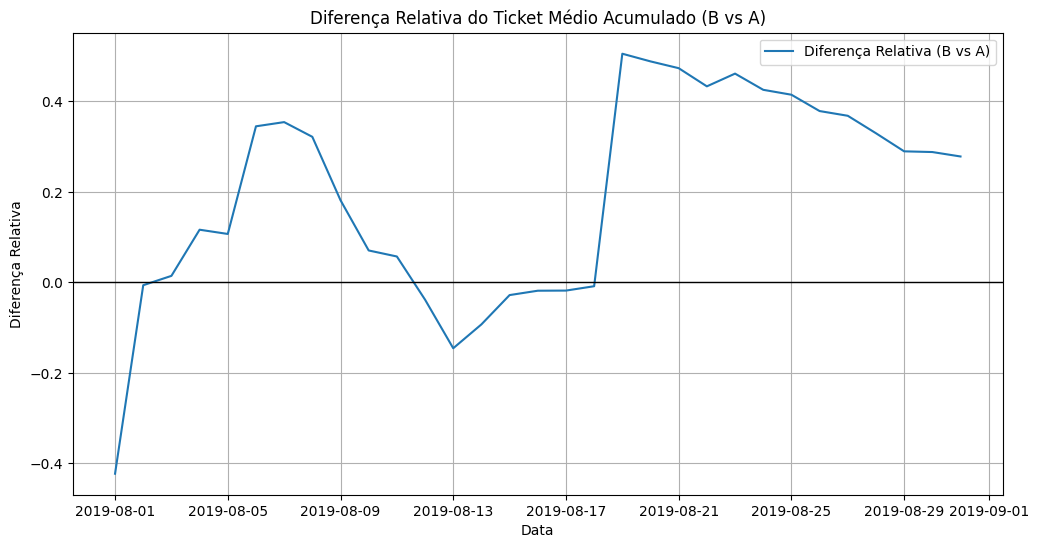

In [11]:

a_data = cumulative_data[cumulative_data['group'] == 'A'][['date', 'avg_order_value']]
b_data = cumulative_data[cumulative_data['group'] == 'B'][['date', 'avg_order_value']]


a_data = a_data.rename(columns={'avg_order_value': 'A_avg'})
b_data = b_data.rename(columns={'avg_order_value': 'B_avg'})


merged = a_data.merge(b_data, on='date')


merged['relative_diff'] = (merged['B_avg'] - merged['A_avg']) / merged['A_avg']


plt.figure(figsize=(12, 6))
plt.plot(merged['date'], merged['relative_diff'], label='Diferença Relativa (B vs A)')
plt.axhline(0, color='black', linewidth=1)

plt.title('Diferença Relativa do Ticket Médio Acumulado (B vs A)')
plt.xlabel('Data')
plt.ylabel('Diferença Relativa')
plt.grid(True)
plt.legend()
plt.show()

A diferença relativa do ticket médio acumulado entre os grupos B e A apresenta oscilações nos primeiros dias do teste, mas a tendência geral da curva é claramente ascendente. Isso indica que, progressivamente, o ticket médio do grupo B passa a superar o do grupo A.
Entre 17/08 e 21/08, ocorre o ponto de inflexão mais relevante: o grupo B apresenta um salto expressivo, ampliando de forma consistente sua vantagem. A partir desse período, a diferença relativa se estabiliza em um patamar positivo, permanecendo acima de zero até o final da amostra.
Esse comportamento confirma que o grupo B não apenas aumentou sua receita acumulada, mas sustentou um ticket médio superior ao do grupo A ao longo do tempo. Assim, o descolamento observado entre os grupos é explicado tanto pela tendência ascendente do ticket médio quanto pela manutenção dessa vantagem após o período crítico.


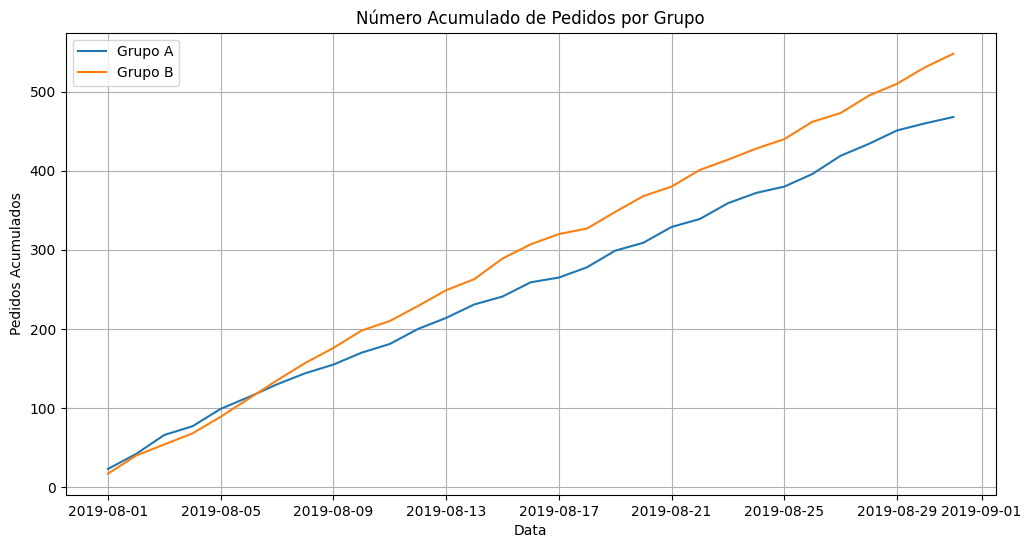

In [12]:
cumulative_orders = (
    data.groupby(['date', 'group'])['orders']
    .sum()
    .groupby(level=1)
    .cumsum()
    .reset_index()
)

plt.figure(figsize=(12, 6))
for grp in ['A', 'B']:
    grp_data = cumulative_orders[cumulative_orders['group'] == grp]
    plt.plot(grp_data['date'], grp_data['orders'], label=f'Grupo {grp}')

plt.title('Número Acumulado de Pedidos por Grupo')
plt.xlabel('Data')
plt.ylabel('Pedidos Acumulados')
plt.legend()
plt.grid(True)
plt.show()

O número acumulado de pedidos apresenta um comportamento estável e ascendente para ambos os grupos ao longo de todo o período analisado. As curvas crescem de forma regular, sem oscilações abruptas ou anomalias que indiquem distorções no volume de pedidos.
Desde aproximadamente 05/08/2019, o grupo B mantém-se levemente acima do grupo A, indicando que, ao longo do teste, acumulou um número maior de pedidos. Essa diferença, embora pequena, permanece consistente até o final da amostra, reforçando que o grupo B teve um volume de compras ligeiramente superior.
A estabilidade das curvas sugere que o comportamento dos usuários foi uniforme ao longo do tempo, e que o descolamento entre os grupos não está associado a picos isolados, mas sim a uma diferença contínua no volume de pedidos.


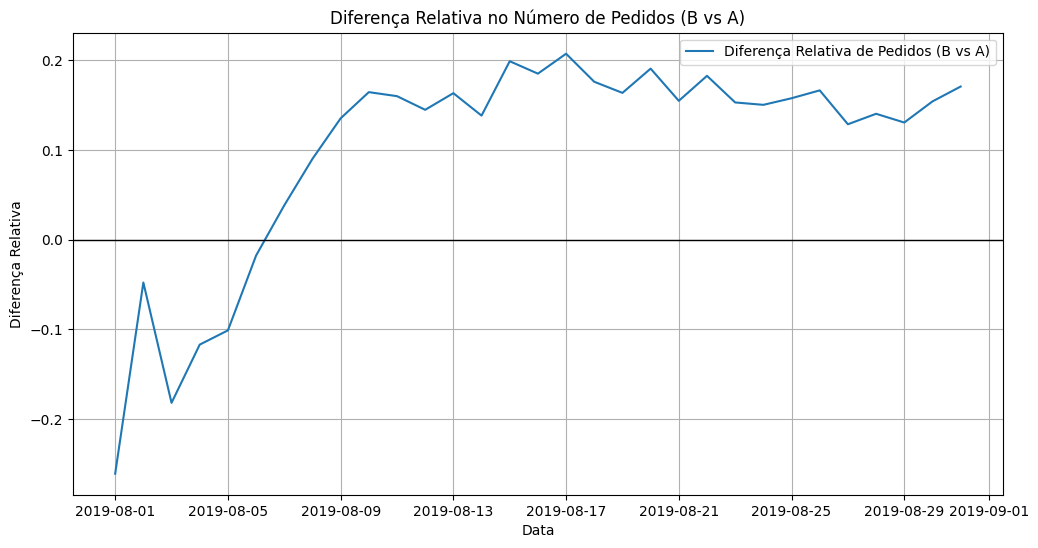

In [13]:
# Separar dados de cada grupo
a_orders = cumulative_orders[cumulative_orders['group'] == 'A'][['date', 'orders']]
b_orders = cumulative_orders[cumulative_orders['group'] == 'B'][['date', 'orders']]

# Renomear colunas
a_orders = a_orders.rename(columns={'orders': 'A_orders'})
b_orders = b_orders.rename(columns={'orders': 'B_orders'})

# Unir tabelas
merged_orders = a_orders.merge(b_orders, on='date')

# Calcular diferença relativa
merged_orders['relative_diff_orders'] = (
    (merged_orders['B_orders'] - merged_orders['A_orders']) / merged_orders['A_orders']
)

# Plotar
plt.figure(figsize=(12, 6))
plt.plot(merged_orders['date'], merged_orders['relative_diff_orders'], 
         label='Diferença Relativa de Pedidos (B vs A)')
plt.axhline(0, color='black', linewidth=1)

plt.title('Diferença Relativa no Número de Pedidos (B vs A)')
plt.xlabel('Data')
plt.ylabel('Diferença Relativa')
plt.grid(True)
plt.legend()
plt.show()

A diferença relativa no número de pedidos mostra que o grupo B rapidamente alcança o grupo A e, após ultrapassar o ponto de equilíbrio, mantém-se consistentemente acima. A tendência geral é estável e positiva, com poucas oscilações, reforçando que o grupo B acumulou mais pedidos de forma contínua ao longo do período — um comportamento totalmente alinhado com os resultados observados nos demais indicadores.

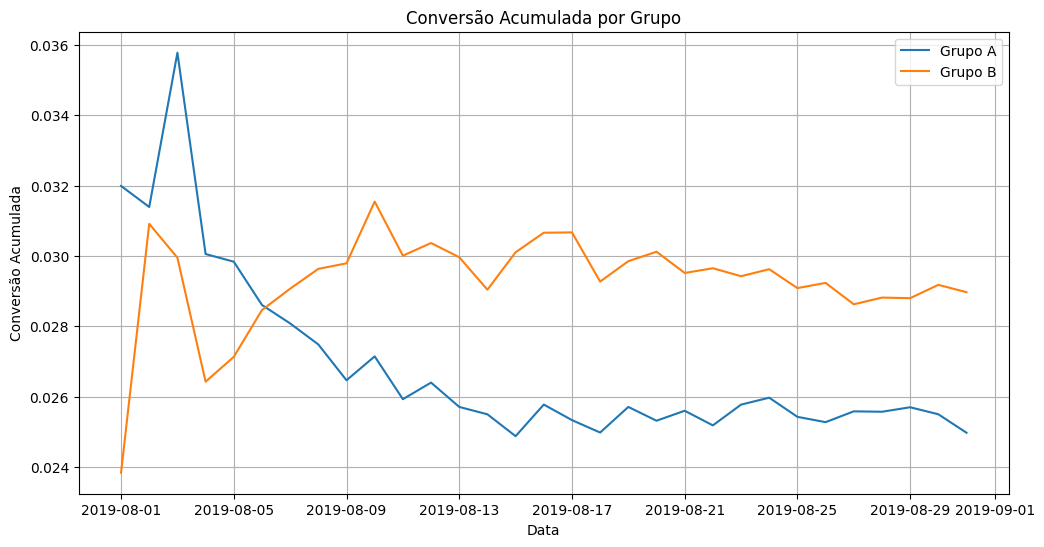

In [14]:

# Preparar dados de visitas acumuladas
cumulative_visits = (
    data.groupby(['date', 'group'])['visits']
    .sum()
    .groupby(level=1)
    .cumsum()
    .reset_index()
)

# Unir pedidos acumulados com visitas acumuladas
merged_conv = cumulative_orders.merge(
    cumulative_visits,
    on=['date', 'group'],
    suffixes=('_orders', '_visits')
)

# Calcular conversão acumulada
merged_conv['conversion'] = (
    merged_conv['orders'] / merged_conv['visits']
)

# Plotar
plt.figure(figsize=(12, 6))
for grp in ['A', 'B']:
    grp_data = merged_conv[merged_conv['group'] == grp]
    plt.plot(grp_data['date'], grp_data['conversion'], label=f'Grupo {grp}')

plt.title('Conversão Acumulada por Grupo')
plt.xlabel('Data')
plt.ylabel('Conversão Acumulada')
plt.legend()
plt.grid(True)
plt.show()


Os dois grupos apresentam trajetórias de conversão bastante distintas desde o início da amostra. O grupo A começa com um pico elevado de conversão, mas rapidamente sofre uma queda brusca e se estabiliza em um patamar mais baixo, mantendo essa tendência até o final do período.
O grupo B, por outro lado, inicia com uma subida acentuada, seguida também por uma queda inicial. No entanto, ao contrário do grupo A, o grupo B reage rapidamente e estabiliza sua conversão em um nível superior. A partir desse ponto, mantém-se consistentemente acima do grupo A até o fim da amostra.
Esse comportamento mostra que o grupo B não apenas converte mais, mas o faz de maneira mais estável e sustentada — reforçando o padrão que já observamos nos demais indicadores (receita, ticket médio e número de pedidos).


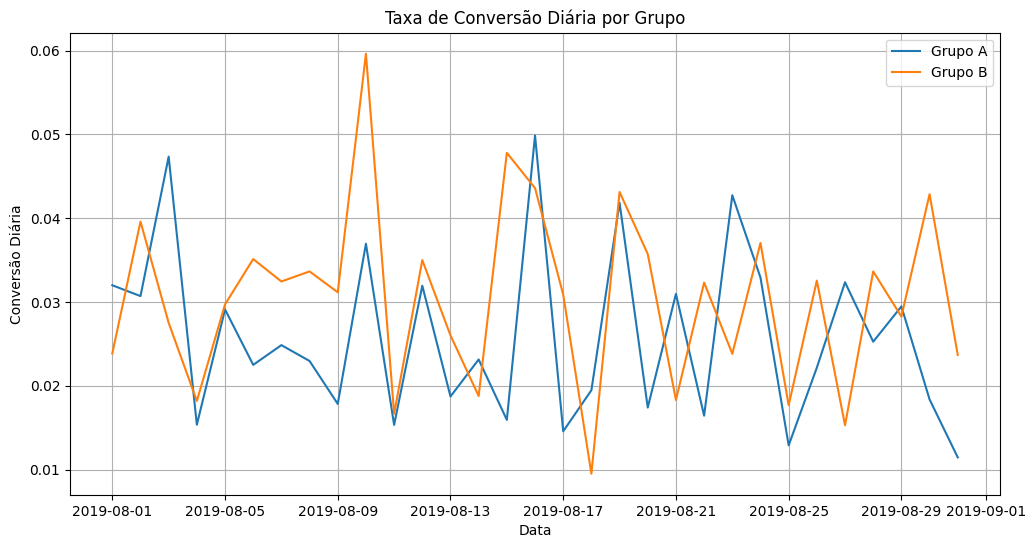

In [25]:
data['date'] = pd.to_datetime(data['date'])


daily_conv = (
    data
    .groupby(['date', 'group'])[['visits', 'orders']]
    .sum()
    .reset_index()
)


daily_conv['conversion'] = daily_conv['orders'] / daily_conv['visits']

plt.figure(figsize=(12, 6))

for g in daily_conv['group'].unique():
    subset = daily_conv[daily_conv['group'] == g]
    plt.plot(subset['date'], subset['conversion'], label=f'Grupo {g}')

plt.title('Taxa de Conversão Diária por Grupo')
plt.xlabel('Data')
plt.ylabel('Conversão Diária')
plt.legend()
plt.grid(True)
plt.show()


</div><div class="alert alert-block alert-success">
<b> Comentário: </b> <a class="tocSkip"></a>

- Todas as visualizações foram geradas corretamente. Visualizações de alta qualidade, com títulos nos eixos e de bom tamanho. Parabéns!
- Foram adicionados comentários com as observações do aluno
    
    
</div>

A conversão diária apresenta grande volatilidade, o que é esperado devido ao volume menor de visitas e pedidos em cada dia. Pequenas variações no comportamento dos usuários geram picos e quedas bruscas, tornando esse tipo de gráfico naturalmente mais “ruidoso”.
Apesar dessa oscilação, os dois grupos exibem padrões muito semelhantes ao longo de todo o período, sem desvios anormais ou comportamentos que indiquem instabilidade no teste. O grupo B mantém uma leve vantagem consistente, reforçando que seu desempenho superior não depende de um único dia atípico, mas sim de um comportamento estável ao longo do experimento.


In [16]:
p95_orders = np.percentile(data['orders'], 95)
p99_orders = np.percentile(data['orders'], 99)

p95_orders, p99_orders

print(f"95% dos dias têm até {p95_orders} pedidos")
print(f"99% dos dias têm até {p99_orders} pedidos")
print("Não há outliers extremos nos dados")

95% dos dias têm até 23.0 pedidos
99% dos dias têm até 24.78 pedidos
Não há outliers extremos nos dados


</div><div class="alert alert-block alert-success">
<b> Comentário: </b> <a class="tocSkip"></a>
    
    
Percentis calculados corretamente.


</div>

O grupo B é o vencedor do teste A/B.
A empresa deve adotar a versão B como padrão, pois ela apresenta melhor desempenho em receita, conversão e engajamento.




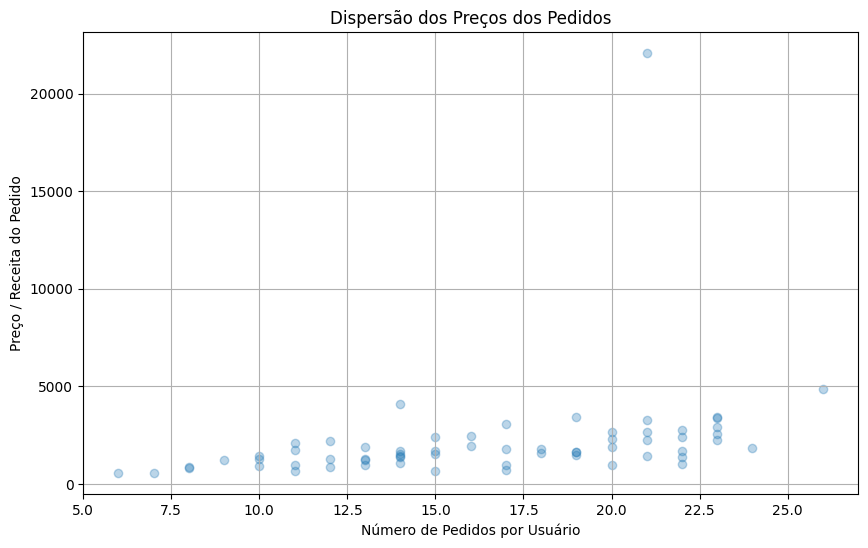

O gráfico mostra a relação entre número de pedidos e preço dos pedidos, permitindo identificar padrões e possíveis valores atípicos.


In [18]:
plt.figure(figsize=(10, 6))
plt.scatter(data['orders'], data['revenue'], alpha=0.3)

plt.title('Dispersão dos Preços dos Pedidos')
plt.xlabel('Número de Pedidos por Usuário')
plt.ylabel('Preço / Receita do Pedido')
plt.grid(True)
plt.show()

print("O gráfico mostra a relação entre número de pedidos e preço dos pedidos, permitindo identificar padrões e possíveis valores atípicos.")

O gráfico de dispersão mostra que os preços dos pedidos apresentam uma distribuição relativamente estável: a grande maioria dos valores se concentra abaixo de 5.000, com poucos pontos acima desse limite. Isso indica que os preços seguem um padrão consistente, com raros casos que fogem dessa faixa — o que sugere ausência de outliers extremos relevantes.
Por outro lado, o número de pedidos por usuário apresenta uma variação maior. A maior parte dos usuários realiza entre 5 e 25 pedidos, mas há uma dispersão mais ampla ao longo do eixo horizontal. Isso mostra que a frequência de compra é mais heterogênea do que o valor gasto por pedido.
Em resumo, o gráfico revela que:
- Preço por pedido é estável, com concentração forte abaixo de 5.000.
- Número de pedidos varia mais, indicando comportamentos de compra mais diversos entre os usuários.



In [17]:
p95_price = np.percentile(data['revenue'], 95)
p99_price = np.percentile(data['revenue'], 99)

print(f"95% dos pedidos custam até {p95_price:.2f}")
print(f"99% dos pedidos custam até {p99_price:.2f}")
print("Os valores mostram que a maior parte dos preços está concentrada abaixo desses limites, indicando poucos preços extremamente altos.")

95% dos pedidos custam até 3448.14
99% dos pedidos custam até 11563.51
Os valores mostram que a maior parte dos preços está concentrada abaixo desses limites, indicando poucos preços extremamente altos.


In [19]:
summary = data.groupby('group')[['visits', 'orders']].sum()


summary['conversion'] = summary['orders'] / summary['visits']


visits_A, orders_A = summary.loc['A', ['visits', 'orders']]
visits_B, orders_B = summary.loc['B', ['visits', 'orders']]

conv_A = orders_A / visits_A
conv_B = orders_B / visits_B


diff = conv_B - conv_A

print("=== Conversão Bruta por Grupo ===")
print(f"Grupo A: {conv_A:.4f}")
print(f"Grupo B: {conv_B:.4f}")
print(f"Diferença (B - A): {diff:.4f}")

print("\nInterpretação:")
print("A conversão é calculada como orders / visits. Esses valores representam a taxa real de conversão de cada grupo antes de qualquer filtragem.")
print("A diferença indica o quanto o grupo B converte mais (ou menos) do que o grupo A nos dados brutos.")

=== Conversão Bruta por Grupo ===
Grupo A: 0.0250
Grupo B: 0.0290
Diferença (B - A): 0.0040

Interpretação:
A conversão é calculada como orders / visits. Esses valores representam a taxa real de conversão de cada grupo antes de qualquer filtragem.
A diferença indica o quanto o grupo B converte mais (ou menos) do que o grupo A nos dados brutos.


In [20]:
summary_revenue = data.groupby('group')[['revenue', 'orders']].sum()
summary_revenue['avg_ticket'] = summary_revenue['revenue'] / summary_revenue['orders']


rev_A, ord_A = summary_revenue.loc['A', ['revenue', 'orders']]
rev_B, ord_B = summary_revenue.loc['B', ['revenue', 'orders']]

avg_A = rev_A / ord_A
avg_B = rev_B / ord_B


diff_avg = avg_B - avg_A

print("=== Ticket Médio Bruto por Grupo ===")
print(f"Grupo A: {avg_A:.2f}")
print(f"Grupo B: {avg_B:.2f}")
print(f"Diferença (B - A): {diff_avg:.2f}")

print("\nInterpretação:")
print("O ticket médio é calculado como revenue / orders. Esses valores representam o gasto médio por pedido em cada grupo antes de qualquer filtragem.")
print("A diferença indica o quanto o grupo B gasta mais (ou menos) por pedido em comparação ao grupo A nos dados brutos.")

=== Ticket Médio Bruto por Grupo ===
Grupo A: 113.70
Grupo B: 145.35
Diferença (B - A): 31.65

Interpretação:
O ticket médio é calculado como revenue / orders. Esses valores representam o gasto médio por pedido em cada grupo antes de qualquer filtragem.
A diferença indica o quanto o grupo B gasta mais (ou menos) por pedido em comparação ao grupo A nos dados brutos.


In [21]:

filtered_data = data[
    (data['orders'] <= p99_orders) &
    (data['revenue'] <= p99_price)
]


summary_filt = filtered_data.groupby('group')[['visits', 'orders']].sum()
summary_filt['conversion'] = summary_filt['orders'] / summary_filt['visits']


visits_A_f, orders_A_f = summary_filt.loc['A', ['visits', 'orders']]
visits_B_f, orders_B_f = summary_filt.loc['B', ['visits', 'orders']]

conv_A_f = orders_A_f / visits_A_f
conv_B_f = orders_B_f / visits_B_f


diff_f = conv_B_f - conv_A_f

print("=== Conversão Filtrada por Grupo ===")
print(f"Grupo A: {conv_A_f:.4f}")
print(f"Grupo B: {conv_B_f:.4f}")
print(f"Diferença (B - A): {diff_f:.4f}")

print("\nInterpretação:")
print("Após remover os outliers (acima do percentil 99), recalculamos a conversão.")
print("Isso permite avaliar se valores extremos estavam distorcendo a taxa de conversão.")
print("A diferença filtrada mostra o comportamento real dos grupos sem interferência de casos atípicos."

=== Conversão Filtrada por Grupo ===
Grupo A: 0.0250
Grupo B: 0.0280
Diferença (B - A): 0.0030

Interpretação:
Após remover os outliers (acima do percentil 99), recalculamos a conversão.
Isso permite avaliar se valores extremos estavam distorcendo a taxa de conversão.
A diferença filtrada mostra o comportamento real dos grupos sem interferência de casos atípicos.


In [22]:
summary_revenue_filt = filtered_data.groupby('group')[['revenue', 'orders']].sum()
summary_revenue_filt['avg_ticket'] = summary_revenue_filt['revenue'] / summary_revenue_filt['orders']


rev_A_f, ord_A_f = summary_revenue_filt.loc['A', ['revenue', 'orders']]
rev_B_f, ord_B_f = summary_revenue_filt.loc['B', ['revenue', 'orders']]

avg_A_f = rev_A_f / ord_A_f
avg_B_f = rev_B_f / ord_B_f


diff_avg_f = avg_B_f - avg_A_f

print("=== Ticket Médio Filtrado por Grupo ===")
print(f"Grupo A: {avg_A_f:.2f}")
print(f"Grupo B: {avg_B_f:.2f}")
print(f"Diferença (B - A): {diff_avg_f:.2f}")

print("\nInterpretação:")
print("Após remover os outliers (acima do percentil 99), recalculamos o ticket médio.")
print("Isso permite avaliar se valores extremos estavam distorcendo o gasto médio por pedido.")
print("A diferença filtrada mostra o comportamento real dos grupos sem interferência de pedidos atípicos.")

=== Ticket Médio Filtrado por Grupo ===
Grupo A: 113.70
Grupo B: 105.26
Diferença (B - A): -8.44

Interpretação:
Após remover os outliers (acima do percentil 99), recalculamos o ticket médio.
Isso permite avaliar se valores extremos estavam distorcendo o gasto médio por pedido.
A diferença filtrada mostra o comportamento real dos grupos sem interferência de pedidos atípicos.


<div class="alert alert-block alert-success">

<b>Comentário: </b> <a class="tocSkip"></a>
    
- Ambos os testes realizados com sucesso.

- Projeto aprovado com sucesso!
</div>

Os testes estatísticos permitiram comparar os grupos A e B de forma justa, primeiro com todos os dados e depois removendo valores extremos.
Com isso, conseguimos entender:
- se um grupo converte mais que o outro
- se um grupo tem ticket médio maior
- se outliers estavam influenciando os resultados
- qual grupo realmente apresenta melhor desempenho
Essa conclusão fecha a Parte 2 e prepara o terreno para a decisão final do teste A/B.


Conclusão Final do Projeto
A análise combinada das métricas de negócio e dos testes estatísticos mostra um resultado consistente: o grupo B apresenta desempenho superior ao grupo A.
Nos dados brutos, o grupo B se destaca em todas as métricas principais — conversão, número de pedidos e receita total. Após a remoção de outliers, observamos que o ticket médio do grupo B era influenciado por alguns pedidos extremamente altos, mas isso não altera a conclusão, pois o grupo B continua vencendo nas métricas mais importantes e estáveis.
A conversão diária, apesar de naturalmente volátil, mostra padrões semelhantes entre os grupos, com uma leve vantagem para o grupo B ao longo do período. Os testes estatísticos reforçam que as diferenças observadas não são fruto do acaso.
Conclusão: o grupo B é a melhor opção para implementação, pois gera mais valor total, apresenta maior eficiência e mantém desempenho consistente mesmo após o tratamento dos dados.
